# DCLM-Edu GPT Optimizer and OptiSelect Comprehensive Demo

This notebook trains a compact decoder-only GPT on DCLM-Edu and drives the optimizer and OptiSelect online data-selection settings from `demo_config.yaml`.

It includes standard and OptiSelect variants for:

- AdamW
- d-Muon
- SGD
- signSGD
- Lion
- Signum
- AdEMAMix
- SophiaG

The dataset is DCLM-Edu from `HuggingFaceTB/dclm-edu`. The notebook streams the configured shards, uses the configured `edu_int_score` filter only when `dataset.min_edu_score` is not null, trains a byte-level BPE tokenizer, and writes tokenized `train.bin`, `val.bin`, document-length arrays, document score arrays, `tokenizer.json`, and metadata under the configured `datasets/dclm-edu-comprehensive` directory.

## Paper-style setup summary

**Models and training.** The default configuration is a compact GPT rather than the 125M/350M/760M/1.3B Llama sweep. Width is derived from `depth * aspect_ratio` and rounded to `head_dim`; by default this gives 8 layers, 512 hidden size, 8 heads, sequence length 1024, bf16 autocast, and a 131k-token update batch. Runs use fixed token budgets from `demo_config.yaml`: 1B update tokens for standard runs and 1B selected/update tokens for OptiSelect with 4x candidate oversampling. The result JSON separately records candidate-scored tokens and implementation-level processed tokens.

**Optimizers.** The sweep covers AdamW, d-Muon, SGD, signSGD, Lion, Signum, AdEMAMix, and SophiaG with optimizer-specific learning rates from the YAML. The notebook intentionally rejects configurations where d-Muon, SophiaG, signSGD, Lion, Signum, or SGD silently reuse AdamW's learning rate, because that creates misleading training/validation gaps.

**Data selection proxy.** OptiSelect draws `candidate_multiplier * B` DCLM-Edu candidates and selects `B`. Set `selection.proxy_source: dclm_edu_heldout` to use held-out DCLM-Edu documents, or `selection.proxy_source: downstream` with `selection.proxy_tasks` to build a task-aware proxy from HellaSwag, ARC-Easy, ARC-Challenge, and OpenBookQA validation examples. Downstream proxy text is downloaded through Hugging Face Datasets and tokenized with this notebook's byte-BPE tokenizer, so it remains compatible with the single-GPU demo model.

**Evaluation.** During training the notebook reports held-out DCLM-Edu validation loss/perplexity. The final optional evaluation cell uses `lm-evaluation-harness` through a custom `LM` wrapper for the notebook model on HellaSwag, ARC-Easy, ARC-Challenge, WinoGrande, PIQA, LAMBADA, OpenBookQA, MMLU, and GSM8K. Leave `evaluation.lm_eval_harness.limit: null` for reportable numbers.


## 0. Install Runtime Dependencies

Run this once in a fresh notebook environment. The local repo supplies the optimizer and OptiSelect implementations.


In [1]:
%pip install -q --upgrade "typing_extensions>=4.13.2" "datasets>=2.19.0" "lm_eval>=0.4.12" tokenizers tiktoken matplotlib tqdm huggingface_hub pyyaml fsspec pyarrow


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy 3.7.2 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.
weasel 0.3.4 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load Config, Repo Code, and Device

All sweep knobs live in `demo_config.yaml`. The notebook code reads that file and imports optimizer/selection classes from this repository.


In [1]:
import gc
import hashlib
import json
import math
import os
import random
import sys
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint
import yaml
from IPython.display import clear_output, display
from tqdm.auto import tqdm


def find_repo_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    candidates.append(Path('/mloscratch/homes/aabdolla/llm-optimizer-benchmark'))
    for candidate in candidates:
        if (candidate / 'src' / 'optim').is_dir() and (candidate / 'src' / 'selection').is_dir():
            return candidate.resolve()
    raise RuntimeError('Could not find llm-optimizer-benchmark repo root.')


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / 'src'
CONFIG_PATH = SRC_DIR / 'demo_config.yaml'

with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

# Prefer the detected repo root if the YAML was copied to a different machine.
CFG['paths']['repo_root'] = str(REPO_ROOT)

# Optional single-GPU notebook proxy switch. You can either edit demo_config.yaml
# or set these fields here before running the derived-settings/training cells.
# Valid sources: 'dclm_edu_heldout' and 'downstream'.
# Example:
#   CFG['selection']['proxy_source'] = 'downstream'
#   CFG['selection']['proxy_tasks'] = ['hellaswag', 'arc_easy', 'arc_challenge', 'openbookqa']
#   CFG['paths']['results_dir'] = '/mloscratch/homes/aabdolla/results/demo_dclm_notebook_downstream_proxy'
_proxy_source_override = os.environ.get('DEMO_PROXY_SOURCE', '').strip()
_proxy_tasks_override = os.environ.get('DEMO_PROXY_TASKS', '').strip()
if _proxy_source_override:
    CFG['selection']['proxy_source'] = _proxy_source_override
if _proxy_tasks_override:
    CFG['selection']['proxy_tasks'] = [x.strip() for x in _proxy_tasks_override.split(',') if x.strip()]

# The top-level data folder named `datasets/` can shadow Hugging Face's
# `datasets` package when this notebook is launched from the home directory.
# Keep imports deterministic by relying on explicit repo/src paths instead.
cwd_str = str(Path.cwd().resolve())
sys.path = [p for p in sys.path if p not in ('', cwd_str)]
sys.path.insert(0, str(SRC_DIR))
_bad_datasets = sys.modules.get('datasets')
if _bad_datasets is not None and not hasattr(_bad_datasets, 'load_dataset'):
    del sys.modules['datasets']

DATASETS_DIR = Path(CFG['paths']['datasets_dir']).expanduser()
RESULTS_DIR = Path(CFG['paths']['results_dir']).expanduser()
HF_CACHE_DIR = Path(CFG['paths']['hf_cache_dir']).expanduser()
for p in (DATASETS_DIR, RESULTS_DIR, HF_CACHE_DIR):
    p.mkdir(parents=True, exist_ok=True)

os.environ.setdefault('HF_HOME', str(HF_CACHE_DIR / 'home'))
os.environ.setdefault('HF_DATASETS_CACHE', str(HF_CACHE_DIR / 'datasets'))
os.environ.setdefault('HF_HUB_CACHE', str(HF_CACHE_DIR / 'hub'))

from optim.ademamix import AdEMAMix
from optim.lion import Lion
from optim.muon import DistributedMuon
from optim.sign import Signum
from optim.sophia import SophiaG
from selection.influence_scoring import InfluenceConfig
from selection.optiselect_engine import OptiSelectEngine

if CFG['training']['device'] == 'auto':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = torch.device(CFG['training']['device'])

if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name()
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB VRAM)')
else:
    print('WARNING: no CUDA GPU found. Most runs will be slow, and d-Muon requires CUDA.')

print(f'Repo: {REPO_ROOT}')
print(f'Config: {CONFIG_PATH}')
print(f'Datasets: {DATASETS_DIR}')
print(f'PyTorch: {torch.__version__}')

def autocast_context():
    dtype_name = CFG['training']['dtype']
    if device.type == 'cuda':
        dtype = {'bfloat16': torch.bfloat16, 'float16': torch.float16, 'float32': torch.float32}[dtype_name]
        return torch.amp.autocast(device_type='cuda', dtype=dtype)
    if device.type == 'cpu' and dtype_name == 'bfloat16':
        return torch.amp.autocast(device_type='cpu', dtype=torch.bfloat16)
    return nullcontext()


/home/aabdolla/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA H100 80GB HBM3 (79.2 GB VRAM)
Repo: /mloscratch/homes/aabdolla/llm-optimizer-benchmark
Config: /mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/demo_config.yaml
Datasets: /mloscratch/homes/aabdolla/datasets
PyTorch: 2.3.0a0+ebedce2


## 2. Derived Settings and LR Safety Checks

The important guard here is that optimizer families do not silently inherit AdamW's learning rate. d-Muon, SophiaG, signSGD, Lion, Signum, and SGD are checked explicitly against AdamW.


In [2]:
def model_dimensions(cfg):
    depth = int(cfg['model']['depth'])
    aspect = int(cfg['model']['aspect_ratio'])
    head_dim = int(cfg['model']['head_dim'])
    base_dim = depth * aspect
    model_dim = ((base_dim + head_dim - 1) // head_dim) * head_dim
    num_heads = model_dim // head_dim
    return model_dim, num_heads


def effective_batch_tokens(cfg):
    return int(cfg['training']['device_batch_size']) * int(cfg['model']['max_seq_len'])


def planned_grad_accum_steps(cfg):
    per_fwdbwd = effective_batch_tokens(cfg)
    requested = int(cfg['training']['total_batch_tokens'])
    if requested % per_fwdbwd != 0:
        raise ValueError(
            f"total_batch_tokens={requested:,} must be an exact multiple of "
            f"device_batch_size*max_seq_len={per_fwdbwd:,} for precise token accounting."
        )
    return max(1, requested // per_fwdbwd)


def update_batch_tokens(cfg):
    return planned_grad_accum_steps(cfg) * effective_batch_tokens(cfg)


def update_batch_examples(cfg):
    return planned_grad_accum_steps(cfg) * int(cfg['training']['device_batch_size'])


def resolve_run_iterations(optiselect, cfg):
    raw = cfg['training'].get('iterations')
    if isinstance(raw, int):
        return int(raw)
    if raw == 'auto_from_token_budget':
        key = 'optiselect_update_tokens' if optiselect else 'standard_update_tokens'
        target_tokens = int(cfg['training'][key])
        return int(math.ceil(target_tokens / update_batch_tokens(cfg)))
    if raw is None:
        return None
    raise ValueError(f"Unknown training.iterations value: {raw!r}")


def target_update_tokens_for_run(optiselect, cfg):
    key = 'optiselect_update_tokens' if optiselect else 'standard_update_tokens'
    return int(cfg['training'].get(key, 0) or 0)


def resolve_eval_batches(cfg, final=False):
    raw_key = 'final_eval_batches' if final else 'eval_batches'
    token_key = 'final_eval_tokens' if final else 'eval_tokens'
    raw = cfg['training'][raw_key]
    if isinstance(raw, int):
        return int(raw)
    expected = 'auto_from_final_eval_tokens' if final else 'auto_from_eval_tokens'
    if raw == expected:
        return int(math.ceil(int(cfg['training'][token_key]) / effective_batch_tokens(cfg)))
    raise ValueError(f"Unknown training.{raw_key} value: {raw!r}")


def resolve_sophia_bs_examples(cfg, opt_cfg):
    raw = opt_cfg.get('sophia_bs', 'auto_effective_batch_examples')
    if raw == 'auto_effective_batch_examples':
        return update_batch_examples(cfg)
    return int(raw)


def scaled_lr(opt_key, cfg):
    opt_cfg = cfg['optimizers'][opt_key]
    lr = float(opt_cfg['lr'])
    scaling = cfg.get('scaling', {})
    if not scaling.get('enabled', False):
        return lr
    model_dim, _ = model_dimensions(cfg)
    width_power = float(opt_cfg.get('width_power', scaling.get('default_width_power', 0.0)))
    batch_power = float(opt_cfg.get('batch_power', scaling.get('default_batch_power', 0.0)))
    width_scale = (model_dim / float(scaling['reference_n_embd'])) ** width_power
    batch_scale = (int(cfg['training']['total_batch_tokens']) / float(scaling['reference_batch_tokens'])) ** batch_power
    return lr * width_scale * batch_scale


def validate_learning_rates(cfg):
    adamw_lr = scaled_lr('adamw', cfg)
    bad = []
    for opt_key in cfg.get('safety', {}).get('forbid_same_lr_as_adamw_for', []):
        if math.isclose(scaled_lr(opt_key, cfg), adamw_lr, rel_tol=0.0, abs_tol=1e-15):
            bad.append(opt_key)
    if bad:
        raise ValueError(
            'Unsafe LR config: these optimizers share AdamW LR even though they need their own scale: '
            + ', '.join(bad)
        )


SUPPORTED_DOWNSTREAM_PROXY_TASKS = {'hellaswag', 'arc_easy', 'arc_challenge', 'openbookqa'}


def validate_selection_proxy(cfg):
    sel_cfg = cfg.get('selection', {})
    proxy_source = sel_cfg.get('proxy_source', 'dclm_edu_heldout')
    if proxy_source not in {'dclm_edu_heldout', 'downstream'}:
        raise ValueError("selection.proxy_source must be one of: dclm_edu_heldout, downstream")
    if proxy_source == 'downstream':
        tasks = [str(t).strip() for t in sel_cfg.get('proxy_tasks', []) if str(t).strip()]
        if not tasks:
            raise ValueError("selection.proxy_source='downstream' requires selection.proxy_tasks.")
        unknown = sorted(set(tasks) - SUPPORTED_DOWNSTREAM_PROXY_TASKS)
        if unknown:
            raise ValueError(
                f"Unknown downstream proxy task(s): {unknown}. "
                f"Supported: {sorted(SUPPORTED_DOWNSTREAM_PROXY_TASKS)}"
            )


validate_learning_rates(CFG)
validate_selection_proxy(CFG)
model_dim, num_heads = model_dimensions(CFG)
grad_accum_steps = planned_grad_accum_steps(CFG)
effective_tokens = grad_accum_steps * effective_batch_tokens(CFG)
standard_iters = resolve_run_iterations(False, CFG)
optiselect_iters = resolve_run_iterations(True, CFG)
eval_batches = resolve_eval_batches(CFG, final=False)
final_eval_batches = resolve_eval_batches(CFG, final=True)

print(f'Model dim: {model_dim}, heads: {num_heads}')
print(f'Gradient accumulation: {grad_accum_steps}')
print(f'Effective update batch: {effective_tokens:,} tokens')
print('\nTraining token budget:')
print(f"  standard:   target={target_update_tokens_for_run(False, CFG):,} update tokens -> {standard_iters:,} updates")
print(f"  OptiSelect: target={target_update_tokens_for_run(True, CFG):,} selected/update tokens -> {optiselect_iters:,} updates")
print(f"  examples/update={update_batch_examples(CFG):,}, sequence_length={CFG['model']['max_seq_len']}")
print('\nValidation budget:')
print(f"  periodic: {eval_batches:,} batches = {eval_batches * effective_batch_tokens(CFG):,} tokens")
print(f"  final:    {final_eval_batches:,} batches = {final_eval_batches * effective_batch_tokens(CFG):,} tokens")
print('\nOptimizer LR table:')
for opt_key, opt_cfg in CFG['optimizers'].items():
    print(f"  {opt_key:9s} lr={scaled_lr(opt_key, CFG):.3e}  display={opt_cfg['display_name']}")

print('\nRun order:')
for run_key in CFG['experiment']['run_keys']:
    run_cfg = CFG['runs'][run_key]
    suffix = 'OptiSelect' if run_cfg['optiselect'] else 'standard'
    print(f"  {run_key:20s} -> {run_cfg['optimizer']:9s} {suffix}")

print('\nSelection proxy:')
print(f"  source={CFG['selection'].get('proxy_source')} size={CFG['selection']['val_proxy_size']} {CFG['selection'].get('proxy_unit', 'documents')}")
if CFG['selection'].get('proxy_source') == 'downstream':
    print('  tasks=' + ', '.join(CFG['selection'].get('proxy_tasks', [])))
print(f"  refresh={CFG['selection']['val_proxy_refresh']} steps, candidate_multiplier={CFG['selection']['candidate_multiplier']}")

if CFG.get('evaluation', {}).get('lm_eval_harness', {}).get('enabled', False):
    print('\nlm-evaluation-harness tasks:')
    print('  ' + ', '.join(CFG['evaluation']['lm_eval_harness']['tasks']))


Model dim: 512, heads: 8
Gradient accumulation: 1
Effective update batch: 131,072 tokens

Training token budget:
  standard:   target=1,000,000,000 update tokens -> 7,630 updates
  OptiSelect: target=1,000,000,000 selected/update tokens -> 7,630 updates
  examples/update=128, sequence_length=1024

Validation budget:
  periodic: 256 batches = 33,554,432 tokens
  final:    1,024 batches = 134,217,728 tokens

Optimizer LR table:
  adamw     lr=3.000e-04  display=AdamW
  d-muon    lr=1.000e-03  display=d-Muon
  sgd       lr=3.000e-02  display=SGD
  signsgd   lr=2.000e-04  display=signSGD
  ademamix  lr=5.000e-04  display=AdEMAMix
  sophia    lr=5.000e-04  display=SophiaG

Run order:
  adamw                -> adamw     standard
  optiselect_adamw     -> adamw     OptiSelect
  d-muon               -> d-muon    standard
  optiselect_d-muon    -> d-muon    OptiSelect
  sgd                  -> sgd       standard
  optiselect_sgd       -> sgd       OptiSelect
  signsgd              -> signsgd   

## 3. Prepare DCLM-Edu Under `datasets/`

The cache metadata includes the HF dataset id, shard list, document counts, score filter, and tokenizer settings. If any of those change, the notebook rebuilds the local tokenized copy.


In [3]:
from tokenizers import Tokenizer as HFTokenizer
from tokenizers import decoders, models, pre_tokenizers, trainers


def dataset_fingerprint(cfg):
    relevant = {
        'dataset': cfg['dataset'],
        'tokenizer': cfg['tokenizer'],
    }
    blob = json.dumps(relevant, sort_keys=True).encode('utf-8')
    return hashlib.sha256(blob).hexdigest()[:16]


def dclm_cache_paths(cfg):
    local_dir = DATASETS_DIR / cfg['dataset']['local_dir']
    local_dir.mkdir(parents=True, exist_ok=True)
    return {
        'dir': local_dir,
        'train': local_dir / 'train.bin',
        'val': local_dir / 'val.bin',
        'train_len': local_dir / 'train.len.npy',
        'val_len': local_dir / 'val.len.npy',
        'train_score': local_dir / 'train.edu_score.npy',
        'val_score': local_dir / 'val.edu_score.npy',
        'tokenizer': local_dir / 'tokenizer.json',
        'metadata': local_dir / 'metadata.json',
    }


def cache_is_valid(paths, cfg):
    needed = [
        paths['train'], paths['val'], paths['train_len'], paths['val_len'],
        paths['train_score'], paths['val_score'], paths['tokenizer'], paths['metadata'],
    ]
    if not all(p.exists() for p in needed):
        return False
    try:
        metadata = json.loads(paths['metadata'].read_text())
    except Exception:
        return False
    return metadata.get('fingerprint') == dataset_fingerprint(cfg)


def stream_dclm_edu_texts(cfg):
    from datasets import load_dataset

    ds_cfg = cfg['dataset']
    total_needed = int(ds_cfg['num_train_docs']) + int(ds_cfg['num_val_docs'])
    hf_dataset = ds_cfg['hf_dataset']
    data_files = [f"hf://datasets/{hf_dataset}/{rel}" for rel in ds_cfg['data_files']]

    print('Streaming DCLM-Edu from explicit shards:')
    for rel in ds_cfg['data_files']:
        print(f'  - {hf_dataset}/{rel}')

    ds = load_dataset(
        'parquet',
        data_files={'train': data_files},
        split='train',
        streaming=bool(ds_cfg.get('streaming', True)),
    )

    text_col = ds_cfg['text_column']
    score_col = ds_cfg['score_column']
    min_score = ds_cfg.get('min_edu_score', None)
    texts = []
    scores = []

    with tqdm(total=total_needed, desc='DCLM-Edu docs') as pbar:
        for ex in ds:
            score = ex.get(score_col, None)
            if min_score is not None:
                if score is None or float(score) < float(min_score):
                    continue
            text = ex.get(text_col, '')
            if not isinstance(text, str) or not text.strip():
                continue
            texts.append(text)
            scores.append(float(score) if score is not None else float('nan'))
            pbar.update(1)
            if len(texts) >= total_needed:
                break

    if len(texts) < total_needed:
        raise RuntimeError(f'Only collected {len(texts)} docs, expected {total_needed}. Add more shards in demo_config.yaml.')
    n_train = int(ds_cfg['num_train_docs'])
    return (
        texts[:n_train],
        texts[n_train:],
        np.asarray(scores[:n_train], dtype=np.float32),
        np.asarray(scores[n_train:], dtype=np.float32),
    )


def train_bpe_tokenizer(train_texts, cfg):
    tok_cfg = cfg['tokenizer']
    tokenizer = HFTokenizer(models.BPE())
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tokenizer.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(
        vocab_size=int(tok_cfg['vocab_size']),
        special_tokens=[tok_cfg['bos_token']],
        initial_alphabet=(
            pre_tokenizers.ByteLevel.alphabet()
            if tok_cfg.get('initial_alphabet', 'byte_level') == 'byte_level' else []
        ),
        min_frequency=int(tok_cfg['min_frequency']),
        show_progress=True,
    )
    tokenizer.train_from_iterator(train_texts, trainer=trainer)
    return tokenizer


def tokenize_texts(texts, tokenizer, bos_token_id, desc):
    all_ids = []
    lengths = []
    batch_size = 1000
    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[start:start + batch_size]
        encoded = tokenizer.encode_batch(batch)
        for enc in encoded:
            doc_ids = [bos_token_id] + enc.ids
            all_ids.extend(doc_ids)
            lengths.append(len(doc_ids))
    vocab_size = tokenizer.get_vocab_size()
    if vocab_size > np.iinfo(np.uint16).max:
        raise ValueError('uint16 token cache requires vocab_size <= 65535.')
    return np.asarray(all_ids, dtype=np.uint16), np.asarray(lengths, dtype=np.int32)


def write_memmap(path, arr):
    mm = np.memmap(path, dtype=np.uint16, mode='w+', shape=arr.shape)
    mm[:] = arr[:]
    mm.flush()
    del mm


def load_token_tensor(path, in_ram=True):
    mm = np.memmap(path, dtype=np.uint16, mode='r')
    if in_ram:
        return torch.from_numpy(np.array(mm, dtype=np.int64))
    return mm


def prepare_dclm_edu(cfg):
    paths = dclm_cache_paths(cfg)
    in_ram = bool(cfg['dataset'].get('load_tokens_in_ram', True))
    if cache_is_valid(paths, cfg):
        print(f"Using cached DCLM-Edu tokens at {paths['dir']}")
        tokenizer = HFTokenizer.from_file(str(paths['tokenizer']))
    else:
        print('Building local DCLM-Edu token cache...')
        train_texts, val_texts, train_scores, val_scores = stream_dclm_edu_texts(cfg)
        tokenizer = train_bpe_tokenizer(train_texts, cfg)
        bos_token_id = tokenizer.token_to_id(cfg['tokenizer']['bos_token'])
        train_arr, train_lens = tokenize_texts(train_texts, tokenizer, bos_token_id, 'Tokenizing train')
        val_arr, val_lens = tokenize_texts(val_texts, tokenizer, bos_token_id, 'Tokenizing val')
        write_memmap(paths['train'], train_arr)
        write_memmap(paths['val'], val_arr)
        np.save(paths['train_len'], train_lens)
        np.save(paths['val_len'], val_lens)
        np.save(paths['train_score'], train_scores)
        np.save(paths['val_score'], val_scores)
        tokenizer.save(str(paths['tokenizer']))
        metadata = {
            'fingerprint': dataset_fingerprint(cfg),
            'hf_dataset': cfg['dataset']['hf_dataset'],
            'data_files': cfg['dataset']['data_files'],
            'min_edu_score': cfg['dataset']['min_edu_score'],
            'num_train_docs': cfg['dataset']['num_train_docs'],
            'num_val_docs': cfg['dataset']['num_val_docs'],
            'train_tokens': int(train_arr.size),
            'val_tokens': int(val_arr.size),
            'train_docs': int(train_lens.size),
            'val_docs': int(val_lens.size),
            'vocab_size': int(tokenizer.get_vocab_size()),
            'score_column': cfg['dataset']['score_column'],
            'train_edu_score_mean': float(np.nanmean(train_scores)),
            'val_edu_score_mean': float(np.nanmean(val_scores)),
            'cache_dir': str(paths['dir']),
        }
        paths['metadata'].write_text(json.dumps(metadata, indent=2))
        del train_texts, val_texts, train_arr, val_arr, train_lens, val_lens, train_scores, val_scores
        gc.collect()

    metadata = json.loads(paths['metadata'].read_text())
    train_data = load_token_tensor(paths['train'], in_ram=in_ram)
    val_data = load_token_tensor(paths['val'], in_ram=in_ram)
    train_lens = np.load(paths['train_len'])
    val_lens = np.load(paths['val_len'])
    train_scores = np.load(paths['train_score'])
    val_scores = np.load(paths['val_score'])
    min_train_tokens = int(cfg['dataset'].get('min_train_tokens', 0) or 0)
    min_val_tokens = int(cfg['dataset'].get('min_val_tokens', 0) or 0)
    if len(train_data) < min_train_tokens:
        raise RuntimeError(
            f"DCLM-Edu train cache has {len(train_data):,} tokens, below "
            f"dataset.min_train_tokens={min_train_tokens:,}. Increase num_train_docs or data_files."
        )
    if len(val_data) < min_val_tokens:
        raise RuntimeError(
            f"DCLM-Edu val cache has {len(val_data):,} tokens, below "
            f"dataset.min_val_tokens={min_val_tokens:,}. Increase num_val_docs or data_files."
        )
    if cfg.get('selection', {}).get('proxy_source', 'dclm_edu_heldout') == 'dclm_edu_heldout' and len(val_lens) < int(cfg['selection']['val_proxy_size']):
        raise RuntimeError(
            f"Validation cache has {len(val_lens):,} documents, but "
            f"selection.val_proxy_size={cfg['selection']['val_proxy_size']:,}."
        )
    bos_token_id = tokenizer.token_to_id(cfg['tokenizer']['bos_token'])
    print(f"Train tokens: {len(train_data):,}")
    print(f"Val tokens:   {len(val_data):,}")
    print(f"Train docs:   {len(train_lens):,}")
    print(f"Val docs:     {len(val_lens):,}")
    print(f"Vocab size:   {tokenizer.get_vocab_size():,}")
    print(f"Local cache:  {paths['dir']}")
    return train_data, val_data, train_lens, val_lens, train_scores, val_scores, tokenizer, bos_token_id, tokenizer.get_vocab_size(), metadata


train_data, val_data, TRAIN_DOC_LENS, VAL_DOC_LENS, TRAIN_DOC_SCORES, VAL_DOC_SCORES, tok_model, BOS_TOKEN_ID, ACTUAL_VOCAB_SIZE, DATA_METADATA = prepare_dclm_edu(CFG)


Using cached DCLM-Edu tokens at /mloscratch/homes/aabdolla/datasets/dclm-edu-comprehensive
Train tokens: 809,982,299
Val tokens:   81,865,355
Train docs:   500,000
Val docs:     50,000
Vocab size:   8,192
Local cache:  /mloscratch/homes/aabdolla/datasets/dclm-edu-comprehensive


## 4. Dataloader

The dataloader samples random contiguous token spans and returns `(input, target)` where the target is shifted by one token.


In [4]:
def _slice_token_source(data_source, start_indices, seq_len):
    if torch.is_tensor(data_source):
        xs = torch.stack([data_source[int(i):int(i) + seq_len] for i in start_indices])
        ys = torch.stack([data_source[int(i) + 1:int(i) + seq_len + 1] for i in start_indices])
    else:
        xs = torch.stack([
            torch.from_numpy(np.asarray(data_source[int(i):int(i) + seq_len], dtype=np.int64))
            for i in start_indices
        ])
        ys = torch.stack([
            torch.from_numpy(np.asarray(data_source[int(i) + 1:int(i) + seq_len + 1], dtype=np.int64))
            for i in start_indices
        ])
    return xs.contiguous(), ys.contiguous()


def make_dataloader(data_source, batch_size, seq_len, device, seed, return_indices=False):
    n = len(data_source) - seq_len - 1
    assert n > 0, f'Data too short ({len(data_source)} tokens) for seq_len={seq_len}'
    gen = torch.Generator(device='cpu')
    gen.manual_seed(int(seed))
    while True:
        ix = torch.randint(0, n, (batch_size,), generator=gen)
        x, y = _slice_token_source(data_source, ix.tolist(), seq_len)
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if return_indices:
            yield x, y, ix.to(device, non_blocking=True)
        else:
            yield x, y


_test_loader = make_dataloader(train_data, 2, 8, device, CFG['training']['seed'])
_xb, _yb = next(_test_loader)
print(f'Batch shape: x={list(_xb.shape)}, y={list(_yb.shape)}')
print(f'Example x: {_xb[0].tolist()}')
print(f'Example y: {_yb[0].tolist()}')
del _test_loader, _xb, _yb


Batch shape: x=[2, 8], y=[2, 8]
Example x: [310, 390, 2074, 1321, 2798, 1464, 286, 6937]
Example y: [390, 2074, 1321, 2798, 1464, 286, 6937, 373]


## 5. Demo GPT Model

This is the original notebook architecture: RMSNorm, RoPE, ReLU-squared MLP, residual/value embeddings, and soft-capped logits. The only API change is that `forward(..., targets=...)` returns a dictionary so the repo's OptiSelect engine can use it.


In [5]:
@dataclass
class GPTConfig:
    sequence_len: int = 1024
    vocab_size: int = 8192
    n_layer: int = 8
    n_head: int = 8
    n_kv_head: int = 8
    n_embd: int = 512
    logit_chunk_tokens: int = 16384


def rms_norm(x):
    return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + 1e-6)


def has_ve(layer_idx, n_layer):
    return layer_idx % 2 == (n_layer - 1) % 2


def apply_rotary_emb(x, cos, sin):
    d = x.shape[-1] // 2
    x1, x2 = x[..., :d], x[..., d:]
    y1 = x1 * cos + x2 * sin
    y2 = x1 * (-sin) + x2 * cos
    return torch.cat([y1, y2], -1)


class CausalSelfAttention(nn.Module):
    def __init__(self, config, layer_idx):
        super().__init__()
        self.n_head = config.n_head
        self.n_kv_head = config.n_kv_head
        self.n_embd = config.n_embd
        self.head_dim = self.n_embd // self.n_head
        assert self.n_embd % self.n_head == 0
        assert self.n_kv_head <= self.n_head and self.n_head % self.n_kv_head == 0

        self.c_q = nn.Linear(self.n_embd, self.n_head * self.head_dim, bias=False)
        self.c_k = nn.Linear(self.n_embd, self.n_kv_head * self.head_dim, bias=False)
        self.c_v = nn.Linear(self.n_embd, self.n_kv_head * self.head_dim, bias=False)
        self.c_proj = nn.Linear(self.n_embd, self.n_embd, bias=False)

        self.ve_gate_channels = min(32, self.n_embd)
        self.ve_gate = (
            nn.Linear(self.ve_gate_channels, self.n_kv_head, bias=False)
            if has_ve(layer_idx, config.n_layer) else None
        )

    def forward(self, x, ve, cos_sin):
        B, T, _ = x.size()
        q = self.c_q(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.c_k(x).view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)
        v = self.c_v(x).view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)

        if ve is not None and self.ve_gate is not None:
            ve_reshaped = ve.view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)
            gate = 2 * torch.sigmoid(self.ve_gate(x[..., :self.ve_gate_channels]))
            gate = gate.transpose(1, 2).unsqueeze(-1)
            v = v + gate * ve_reshaped

        cos, sin = cos_sin
        q = rms_norm(apply_rotary_emb(q, cos, sin))
        k = rms_norm(apply_rotary_emb(k, cos, sin))

        if self.n_kv_head < self.n_head:
            repeat = self.n_head // self.n_kv_head
            k = k.repeat_interleave(repeat, dim=1)
            v = v.repeat_interleave(repeat, dim=1)

        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, -1)
        return self.c_proj(y)


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=False)
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=False)

    def forward(self, x):
        return self.c_proj(F.relu(self.c_fc(x)).square())


class Block(nn.Module):
    def __init__(self, config, layer_idx):
        super().__init__()
        self.attn = CausalSelfAttention(config, layer_idx)
        self.mlp = MLP(config)

    def forward(self, x, ve, cos_sin):
        x = x + self.attn(rms_norm(x), ve, cos_sin)
        x = x + self.mlp(rms_norm(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict({
            'wte': nn.Embedding(config.vocab_size, config.n_embd),
            'h': nn.ModuleList([Block(config, i) for i in range(config.n_layer)]),
        })
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.resid_lambdas = nn.Parameter(torch.ones(config.n_layer))
        self.x0_lambdas = nn.Parameter(torch.zeros(config.n_layer))

        head_dim = config.n_embd // config.n_head
        kv_dim = config.n_kv_head * head_dim
        self.value_embeds = nn.ModuleDict({
            str(i): nn.Embedding(config.vocab_size, kv_dim)
            for i in range(config.n_layer) if has_ve(i, config.n_layer)
        })

        cos, sin = self._precompute_rotary(config.sequence_len, head_dim)
        self.register_buffer('cos', cos, persistent=False)
        self.register_buffer('sin', sin, persistent=False)

    def _precompute_rotary(self, seq_len, head_dim, base=10000):
        inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
        t = torch.arange(seq_len, dtype=torch.float32)
        freqs = torch.outer(t, inv_freq)
        return freqs.cos()[None, None, :, :], freqs.sin()[None, None, :, :]

    @torch.no_grad()
    def init_weights(self):
        n_embd = self.config.n_embd
        s = 3**0.5 * n_embd**-0.5
        nn.init.normal_(self.transformer.wte.weight, mean=0.0, std=1.0)
        nn.init.normal_(self.lm_head.weight, mean=0.0, std=0.001)
        for block in self.transformer.h:
            nn.init.uniform_(block.attn.c_q.weight, -s, s)
            nn.init.uniform_(block.attn.c_k.weight, -s, s)
            nn.init.uniform_(block.attn.c_v.weight, -s, s)
            nn.init.zeros_(block.attn.c_proj.weight)
            nn.init.uniform_(block.mlp.c_fc.weight, -s, s)
            nn.init.zeros_(block.mlp.c_proj.weight)
        self.resid_lambdas.fill_(1.0)
        self.x0_lambdas.fill_(0.1)
        for ve in self.value_embeds.values():
            nn.init.uniform_(ve.weight, -s, s)
        for block in self.transformer.h:
            if block.attn.ve_gate is not None:
                nn.init.zeros_(block.attn.ve_gate.weight)

    def _chunked_lm_loss(self, x, targets, softcap, reduction):
        flat_x = x.reshape(-1, x.size(-1))
        flat_targets = targets.reshape(-1)
        chunk_tokens = int(getattr(self.config, 'logit_chunk_tokens', 0) or flat_x.size(0))
        chunk_tokens = max(1, chunk_tokens)

        if reduction == 'none':
            losses = []
            for start in range(0, flat_x.size(0), chunk_tokens):
                end = min(start + chunk_tokens, flat_x.size(0))
                logits = self.lm_head(flat_x[start:end]).float()
                logits = softcap * torch.tanh(logits / softcap)
                losses.append(F.cross_entropy(
                    logits, flat_targets[start:end],
                    ignore_index=-1, reduction='none',
                ))
            return torch.cat(losses, dim=0).view_as(targets)

        def chunk_loss(chunk_x, chunk_targets):
            logits = self.lm_head(chunk_x).float()
            logits = softcap * torch.tanh(logits / softcap)
            return F.cross_entropy(
                logits, chunk_targets, ignore_index=-1, reduction='sum'
            )

        total_loss = flat_x.new_zeros((), dtype=torch.float32)
        total_count = flat_x.new_zeros((), dtype=torch.float32)
        use_checkpoint = torch.is_grad_enabled() and flat_x.requires_grad
        for start in range(0, flat_x.size(0), chunk_tokens):
            end = min(start + chunk_tokens, flat_x.size(0))
            target_chunk = flat_targets[start:end]
            if use_checkpoint:
                total_loss = total_loss + checkpoint(
                    lambda chunk_x, targets=target_chunk: chunk_loss(chunk_x, targets),
                    flat_x[start:end],
                    use_reentrant=False,
                )
            else:
                total_loss = total_loss + chunk_loss(flat_x[start:end], target_chunk)
            total_count = total_count + (target_chunk != -1).sum().to(torch.float32)

        if reduction == 'sum':
            return total_loss
        if reduction == 'mean':
            return total_loss / total_count.clamp_min(1.0)
        raise ValueError(f'Unsupported reduction: {reduction}')

    def forward(self, idx, targets=None, reduction='mean', get_logits=False, **kwargs):
        B, T = idx.size()
        cos_sin = self.cos[:, :, :T, :], self.sin[:, :, :T, :]
        x = rms_norm(self.transformer.wte(idx))
        x0 = x
        for i, block in enumerate(self.transformer.h):
            x = self.resid_lambdas[i] * x + self.x0_lambdas[i] * x0
            ve = self.value_embeds[str(i)](idx) if str(i) in self.value_embeds else None
            x = block(x, ve, cos_sin)
        x = rms_norm(x)
        softcap = 15

        logits = None
        if get_logits or targets is None:
            logits = self.lm_head(x).float()
            logits = softcap * torch.tanh(logits / softcap)

        loss = None
        if targets is not None:
            if logits is None:
                loss = self._chunked_lm_loss(x, targets, softcap, reduction)
            else:
                loss = F.cross_entropy(
                    logits.view(-1, logits.size(-1)),
                    targets.view(-1),
                    ignore_index=-1,
                    reduction=reduction,
                )
        return {
            'loss': loss,
            'logits': logits if (get_logits or targets is None) else None,
            'aux_losses': {},
        }

    def estimate_flops(self):
        nparams = sum(p.numel() for p in self.parameters())
        ve_numel = sum(ve.weight.numel() for ve in self.value_embeds.values())
        nparams_ex = (
            self.transformer.wte.weight.numel() + ve_numel
            + self.resid_lambdas.numel() + self.x0_lambdas.numel()
        )
        h = self.config.n_head
        q = self.config.n_embd // self.config.n_head
        t = self.config.sequence_len
        attn_flops = self.config.n_layer * 12 * h * q * t
        return 6 * (nparams - nparams_ex) + attn_flops


print('Model definition loaded.')


Model definition loaded.


## 6. Optimizer Construction

These builders use the repo implementations in `src/optim`. d-Muon gets a special parameter split so the small demo vocabulary does not cause embeddings or the LM head to receive Muon updates.


In [6]:
def seed_everything(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))
    torch.set_float32_matmul_precision('high')


def build_model(cfg):
    seed_everything(cfg['training']['seed'])
    model_dim, num_heads = model_dimensions(cfg)
    config = GPTConfig(
        sequence_len=int(cfg['model']['max_seq_len']),
        vocab_size=int(ACTUAL_VOCAB_SIZE),
        n_layer=int(cfg['model']['depth']),
        n_head=int(num_heads),
        n_kv_head=int(num_heads),
        n_embd=int(model_dim),
        logit_chunk_tokens=int(cfg['model'].get('logit_chunk_tokens', 16384)),
    )
    model = GPT(config).to(device)
    model.init_weights()
    return model, config


def should_no_decay(name, param):
    if param.ndim < 2:
        return True
    if 'transformer.wte' in name or 'value_embeds' in name:
        return True
    return False


def adam_style_param_groups(model, weight_decay):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if should_no_decay(name, p) else decay).append(p)
    groups = []
    if decay:
        groups.append({'params': decay, 'weight_decay': float(weight_decay)})
    if no_decay:
        groups.append({'params': no_decay, 'weight_decay': 0.0})
    return groups


def dmuon_param_groups(model, opt_cfg, primary_lr, fallback_lr):
    muon_decay, fallback_decay, fallback_no_decay = [], [], []
    fallback_ids = set()
    for module in model.modules():
        if isinstance(module, nn.Embedding):
            for p in module.parameters(recurse=False):
                fallback_ids.add(id(p))
    for p in model.lm_head.parameters(recurse=False):
        fallback_ids.add(id(p))

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        can_muon = p.ndim >= 2 and id(p) not in fallback_ids and p.size(0) < 10000
        if can_muon:
            muon_decay.append(p)
        elif should_no_decay(name, p):
            fallback_no_decay.append(p)
        else:
            fallback_decay.append(p)

    wd = float(opt_cfg.get('weight_decay', 0.0))
    groups = []
    if muon_decay:
        groups.append({'params': muon_decay, 'lr': float(primary_lr), 'weight_decay': wd})
    if fallback_decay:
        groups.append({'params': fallback_decay, 'lr': float(fallback_lr), 'weight_decay': wd})
    if fallback_no_decay:
        groups.append({'params': fallback_no_decay, 'lr': float(fallback_lr), 'weight_decay': 0.0})
    return groups, fallback_ids


def force_dmuon_adamw_fallback(optimizer, fallback_ids):
    forced = 0
    for group in optimizer.param_groups:
        for p in group['params']:
            if id(p) in fallback_ids or p.ndim < 2:
                optimizer.state[p]['use_muon'] = False
                forced += p.numel()
    return forced


def build_optimizer(model, opt_key, cfg, resolved_iterations=None):
    opt_cfg = cfg['optimizers'][opt_key]
    lr = scaled_lr(opt_key, cfg)
    wd = float(opt_cfg.get('weight_decay', 0.0))

    if opt_key == 'adamw':
        groups = adam_style_param_groups(model, wd)
        opt = torch.optim.AdamW(groups, lr=lr, betas=(float(opt_cfg['beta1']), float(opt_cfg['beta2'])))
        repo_opt_name = 'adamw'
    elif opt_key == 'ademamix':
        groups = adam_style_param_groups(model, wd)
        iterations = int(resolved_iterations or max(1, int(cfg['training'].get('time_budget_sec') or 1)))
        beta3_warmup = opt_cfg.get('beta3_warmup')
        alpha_warmup = opt_cfg.get('alpha_warmup')
        beta3_warmup = iterations if beta3_warmup == 'auto_iterations' else beta3_warmup
        alpha_warmup = iterations if alpha_warmup == 'auto_iterations' else alpha_warmup
        opt = AdEMAMix(
            groups,
            lr=lr,
            betas=(float(opt_cfg['beta1']), float(opt_cfg['beta2']), float(opt_cfg['beta3'])),
            alpha=float(opt_cfg['alpha']),
            beta3_warmup=beta3_warmup,
            alpha_warmup=alpha_warmup,
            weight_decay=wd,
        )
        repo_opt_name = 'ademamix'
    elif opt_key == 'sgd':
        groups = adam_style_param_groups(model, wd)
        opt = torch.optim.SGD(
            groups,
            lr=lr,
            momentum=float(opt_cfg.get('momentum', 0.0)),
            nesterov=bool(opt_cfg.get('nesterov', False)),
            weight_decay=wd,
        )
        repo_opt_name = 'sgd'
    elif opt_key == 'signsgd':
        groups = adam_style_param_groups(model, wd)
        opt = Signum(
            groups,
            lr=lr,
            momentum=0.0,
            dampening=0.0,
            nesterov=False,
            weight_decay=wd,
            sign_update=True,
        )
        repo_opt_name = 'signsgd'
    elif opt_key == 'lion':
        groups = adam_style_param_groups(model, wd)
        opt = Lion(
            groups,
            lr=lr,
            betas=(float(opt_cfg['beta1']), float(opt_cfg['beta2'])),
            weight_decay=wd,
        )
        repo_opt_name = 'lion'
    elif opt_key == 'signum':
        groups = adam_style_param_groups(model, wd)
        opt = Signum(
            groups,
            lr=lr,
            momentum=float(opt_cfg.get('momentum', 0.9)),
            dampening=float(opt_cfg.get('dampening', 0.0)),
            nesterov=bool(opt_cfg.get('nesterov', False)),
            weight_decay=wd,
            sign_update=True,
        )
        repo_opt_name = 'signum'
    elif opt_key == 'sophia':
        groups = adam_style_param_groups(model, wd)
        opt = SophiaG(
            groups,
            lr=lr,
            betas=(float(opt_cfg['beta1']), float(opt_cfg['beta2'])),
            rho=float(opt_cfg['rho']),
            weight_decay=wd,
        )
        repo_opt_name = 'sophiag'
    elif opt_key == 'd-muon':
        if device.type != 'cuda':
            raise RuntimeError('d-Muon requires CUDA because DistributedMuon allocates CUDA update buffers.')
        fallback_lr = float(opt_cfg.get('adamw_lr', CFG['optimizers']['adamw']['lr']))
        groups, fallback_ids = dmuon_param_groups(model, opt_cfg, primary_lr=lr, fallback_lr=fallback_lr)
        opt = DistributedMuon(
            groups,
            lr=lr,
            weight_decay=wd,
            matched_adamw_rms=float(opt_cfg.get('matched_adamw_rms', 0.2)),
            momentum=float(opt_cfg.get('momentum', 0.95)),
            nesterov=bool(opt_cfg.get('nesterov', True)),
            ns_steps=int(opt_cfg.get('muon_ns_steps', 5)),
            adamw_betas=(float(opt_cfg.get('beta1', 0.9)), float(opt_cfg.get('beta2', 0.99))),
        )
        forced = force_dmuon_adamw_fallback(opt, fallback_ids)
        print(f'd-Muon AdamW fallback params forced: {forced:,}')
        repo_opt_name = 'd-muon'
    else:
        raise ValueError(f'Unknown optimizer: {opt_key}')

    for group in opt.param_groups:
        group['initial_lr'] = float(group['lr'])
    return opt, repo_opt_name


_model, _model_cfg = build_model(CFG)
_num_params = sum(p.numel() for p in _model.parameters())
print(f'Demo model params: {_num_params:,} ({_num_params / 1e6:.1f}M)')
print(f'Model config: {asdict(_model_cfg)}')
del _model
if device.type == 'cuda':
    torch.cuda.empty_cache()


Demo model params: 50,332,688 (50.3M)
Model config: {'sequence_len': 1024, 'vocab_size': 8192, 'n_layer': 8, 'n_head': 8, 'n_kv_head': 8, 'n_embd': 512, 'logit_chunk_tokens': 16384}


## 7. Training and OptiSelect Utilities

OptiSelect follows the OPUS online in-batch data selection pattern: draw `candidate_multiplier * B` candidates, score them with optimizer-aware frozen-state geometry, sample `B`, and update on only the selected samples.


In [7]:
def get_lr_multiplier(progress, cfg):
    warmup = float(cfg['training']['warmup_ratio'])
    cooldown = float(cfg['training']['cooldown_ratio'])
    final_frac = float(cfg['training']['final_lr_fraction'])
    progress = min(max(float(progress), 0.0), 1.0)
    if warmup > 0 and progress < warmup:
        return progress / warmup
    if progress < 1.0 - cooldown:
        return 1.0
    if cooldown <= 0:
        return final_frac
    cool = (1.0 - progress) / cooldown
    return cool + (1.0 - cool) * final_frac


def apply_lr_schedule(opt, multiplier):
    for group in opt.param_groups:
        group['lr'] = float(group['initial_lr']) * float(multiplier)


def primary_lr(opt):
    return float(opt.param_groups[0]['lr'])


@torch.no_grad()
def evaluate(model, val_loader, num_batches):
    model.eval()
    total_loss = 0.0
    for _ in range(int(num_batches)):
        x, y = next(val_loader)
        with autocast_context():
            out = model(x, targets=y)
        total_loss += float(out['loss'].item())
    avg_loss = total_loss / max(1, int(num_batches))
    ppl = math.exp(min(avg_loss, 100.0))
    model.train()
    return avg_loss, ppl


def draw_candidate_batch(loader, candidate_multiplier):
    xs, ys, starts = [], [], []
    has_indices = False
    for _ in range(int(candidate_multiplier)):
        batch = next(loader)
        if len(batch) == 3:
            x, y, ix = batch
            starts.append(ix)
            has_indices = True
        else:
            x, y = batch
        xs.append(x)
        ys.append(y)
    cand_x = torch.cat(xs, dim=0)
    cand_y = torch.cat(ys, dim=0)
    cand_starts = torch.cat(starts, dim=0) if has_indices else None
    return cand_x, cand_y, cand_starts


def doc_scores_for_token_starts(token_starts, doc_starts, doc_scores):
    token_starts = np.asarray(token_starts, dtype=np.int64)
    doc_idxs = np.searchsorted(doc_starts, token_starts, side='right') - 1
    doc_idxs = np.clip(doc_idxs, 0, len(doc_scores) - 1)
    return doc_scores[doc_idxs]


def selected_doc_score_stats(candidate_starts, selected_idx, doc_starts, doc_scores):
    if candidate_starts is None or selected_idx is None or len(doc_scores) == 0:
        return None
    cand_starts_np = candidate_starts.detach().cpu().numpy()
    selected_idx_np = selected_idx.detach().cpu().numpy()
    cand_scores = doc_scores_for_token_starts(cand_starts_np, doc_starts, doc_scores)
    selected_scores = cand_scores[selected_idx_np]
    if not np.isfinite(cand_scores).any() or not np.isfinite(selected_scores).any():
        return None
    valid_candidate_scores = cand_scores[np.isfinite(cand_scores)]
    selected_percentiles = np.asarray([
        np.mean(valid_candidate_scores <= score)
        for score in selected_scores[np.isfinite(selected_scores)]
    ], dtype=np.float32)
    return {
        'candidate_edu_score_mean': float(np.nanmean(cand_scores)),
        'selected_edu_score_mean': float(np.nanmean(selected_scores)),
        'selected_edu_score_percentile': float(np.nanmean(selected_percentiles)),
    }


def summarize_doc_score_stats(stats):
    if not stats:
        return None
    keys = sorted({key for item in stats for key in item})
    summary = {'num_selection_batches': int(len(stats))}
    for key in keys:
        values = [float(item[key]) for item in stats if key in item and math.isfinite(float(item[key]))]
        if values:
            summary[f'mean_{key}'] = float(sum(values) / len(values))
    return summary


def capture_candidate_factors(model, opt, engine, cand_x, cand_y, chunk_size):
    actual_b = cand_x.size(0)
    if chunk_size <= 0:
        chunk_size = actual_b
    if actual_b % chunk_size != 0:
        for cs in range(min(chunk_size, actual_b), 0, -1):
            if actual_b % cs == 0:
                chunk_size = cs
                break

    opt.zero_grad(set_to_none=True)
    model.zero_grad(set_to_none=True)
    engine.start_capture()
    chunked_a, chunked_b = {}, {}
    chunked_sketches = {}
    loss_scale = float(chunk_size) / float(actual_b)

    for start in range(0, actual_b, chunk_size):
        end = start + chunk_size
        engine._layer_activations.clear()
        engine._layer_backprops.clear()
        with autocast_context():
            out = model(cand_x[start:end], targets=cand_y[start:end])
        (out['loss'] * loss_scale).backward()
        if engine.config.use_countsketch:
            sketches = engine.build_candidate_sketches(
                engine._layer_activations,
                engine._layer_backprops,
            )
            for name, sketch in sketches.items():
                chunked_sketches.setdefault(name, []).append(sketch.detach())
        else:
            for name, tensor in engine._layer_activations.items():
                chunked_a.setdefault(name, []).append(tensor.detach())
            for name, tensor in engine._layer_backprops.items():
                chunked_b.setdefault(name, []).append(tensor.detach())
        del out

    engine.stop_capture()
    engine._layer_activations = {}
    engine._layer_backprops = {}

    if engine.config.use_countsketch:
        engine._last_candidate_sketches = {
            name: torch.cat(parts, dim=0) if len(parts) > 1 else parts[0]
            for name, parts in chunked_sketches.items()
        }
        if not engine._last_candidate_sketches:
            raise RuntimeError('No CountSketch factors were captured for OptiSelect scoring.')
        return {}, {}

    candidate_activations = {
        name: torch.cat(parts, dim=0) if len(parts) > 1 else parts[0]
        for name, parts in chunked_a.items()
    }
    candidate_backprops = {
        name: torch.cat(parts, dim=0) if len(parts) > 1 else parts[0]
        for name, parts in chunked_b.items()
    }
    if not candidate_activations:
        raise RuntimeError('No Ghost factors were captured for OptiSelect scoring.')
    return candidate_activations, candidate_backprops


def _token_slice_1d(data_source, start, end):
    if torch.is_tensor(data_source):
        return data_source[int(start):int(end)].to(dtype=torch.long)
    return torch.from_numpy(np.asarray(data_source[int(start):int(end)], dtype=np.int64))


def _make_proxy_batches_from_sequences(sequences, batch_size):
    batches = []
    for start in range(0, len(sequences), batch_size):
        stacked = torch.stack(sequences[start:start + batch_size], dim=0).contiguous()
        x = stacked[:, :-1].to(device, non_blocking=True)
        y = stacked[:, 1:].to(device, non_blocking=True)
        batches.append((x, y))
    return batches


def _make_proxy_batches_from_xy(sequences, batch_size):
    batches = []
    for start in range(0, len(sequences), batch_size):
        chunk = sequences[start:start + batch_size]
        x = torch.stack([item[0] for item in chunk], dim=0).contiguous().to(device, non_blocking=True)
        y = torch.stack([item[1] for item in chunk], dim=0).contiguous().to(device, non_blocking=True)
        batches.append((x, y))
    return batches


def build_dclm_heldout_proxy(val_data, val_doc_lens, cfg, refresh_index=0):
    sel_cfg = cfg['selection']
    batch_size = int(sel_cfg.get('proxy_batch_size', cfg['training']['device_batch_size']))
    seq_len = int(cfg['model']['max_seq_len'])
    need = seq_len + 1
    proxy_size = int(sel_cfg['val_proxy_size'])
    starts = np.concatenate([[0], np.cumsum(val_doc_lens)[:-1]]).astype(np.int64)
    rng = np.random.default_rng(int(cfg['training']['seed']) + 10_000 + int(refresh_index) * 104_729)
    replace = proxy_size > len(val_doc_lens)
    doc_idxs = rng.choice(len(val_doc_lens), size=proxy_size, replace=replace)

    sequences = []
    for doc_idx in doc_idxs:
        doc_start = int(starts[int(doc_idx)])
        doc_len = int(val_doc_lens[int(doc_idx)])
        offset = int(rng.integers(0, doc_len - need + 1)) if doc_len > need else 0
        seq = _token_slice_1d(val_data, doc_start + offset, min(doc_start + offset + need, doc_start + doc_len))
        if seq.numel() < need:
            pad = torch.full((need - seq.numel(),), int(BOS_TOKEN_ID), dtype=torch.long)
            seq = torch.cat([seq, pad], dim=0)
        sequences.append(seq[:need])

    return _make_proxy_batches_from_sequences(sequences, batch_size), {
        'source': 'dclm_edu_heldout',
        'counts': {'dclm_edu_heldout': len(sequences)},
    }


_DOWNSTREAM_PROXY_DOC_CACHE = {}


def _load_raw_downstream_dataset(task):
    from datasets import load_dataset

    if task == 'hellaswag':
        return load_dataset('Rowan/hellaswag', split='validation')
    if task == 'arc_easy':
        return load_dataset('allenai/ai2_arc', 'ARC-Easy', split='validation')
    if task == 'arc_challenge':
        return load_dataset('allenai/ai2_arc', 'ARC-Challenge', split='validation')
    if task == 'openbookqa':
        return load_dataset('allenai/openbookqa', 'main', split='validation')
    raise ValueError(f'Unsupported downstream proxy task: {task}')


def _choice_by_answer_key(choices, answer_key):
    labels = [str(x) for x in choices.get('label', [])]
    texts = [str(x) for x in choices.get('text', [])]
    key = str(answer_key)
    if key in labels:
        return texts[labels.index(key)]
    if key.isdigit():
        idx = int(key)
        if 0 <= idx < len(texts):
            return texts[idx]
        one_based = idx - 1
        if 0 <= one_based < len(texts):
            return texts[one_based]
    raise ValueError(f'Could not map answer key {answer_key!r} to choices {labels!r}')


def _format_downstream_proxy_text(task, ex):
    if task == 'hellaswag':
        endings = list(ex['endings'])
        label = int(ex['label'])
        return f"{str(ex['ctx']).strip()} {str(endings[label]).strip()}".strip()
    if task in {'arc_easy', 'arc_challenge'}:
        answer = _choice_by_answer_key(ex['choices'], ex['answerKey'])
        return f"Question: {str(ex['question']).strip()}\nAnswer: {answer.strip()}"
    if task == 'openbookqa':
        answer = _choice_by_answer_key(ex['choices'], ex['answerKey'])
        return f"Question: {str(ex['question_stem']).strip()}\nAnswer: {answer.strip()}"
    raise ValueError(f'Unsupported downstream proxy task: {task}')


def _load_downstream_proxy_docs(task):
    cache_key = (task, DATA_METADATA['fingerprint'], int(BOS_TOKEN_ID))
    if cache_key in _DOWNSTREAM_PROXY_DOC_CACHE:
        return _DOWNSTREAM_PROXY_DOC_CACHE[cache_key]

    ds = _load_raw_downstream_dataset(task)
    docs = []
    skipped = 0
    for ex in ds:
        try:
            text = _format_downstream_proxy_text(task, ex)
            ids = [int(BOS_TOKEN_ID)] + [int(i) for i in tok_model.encode(text).ids]
        except Exception:
            skipped += 1
            continue
        if len(ids) >= 2:
            docs.append(np.asarray(ids, dtype=np.int64))
    if not docs:
        raise RuntimeError(f"Downstream proxy task '{task}' produced zero tokenized examples.")
    if skipped:
        print(f"[WARN] Downstream proxy task '{task}' skipped {skipped} malformed examples.")
    _DOWNSTREAM_PROXY_DOC_CACHE[cache_key] = docs
    return docs


def _sample_downstream_xy(ids, seq_len, rng):
    need = seq_len + 1
    if len(ids) > need:
        offset = int(rng.integers(0, len(ids) - need + 1))
        ids = ids[offset:offset + need]
    x = torch.full((seq_len,), int(BOS_TOKEN_ID), dtype=torch.long)
    y = torch.full((seq_len,), -1, dtype=torch.long)
    ids_t = torch.from_numpy(np.asarray(ids, dtype=np.int64)).to(dtype=torch.long)
    valid_targets = max(0, min(seq_len, ids_t.numel() - 1))
    if valid_targets > 0:
        x[:valid_targets] = ids_t[:valid_targets]
        y[:valid_targets] = ids_t[1:valid_targets + 1]
    return x, y, valid_targets


def build_downstream_validation_proxy(cfg, refresh_index=0):
    sel_cfg = cfg['selection']
    tasks = [str(t).strip() for t in sel_cfg.get('proxy_tasks', []) if str(t).strip()]
    unknown = sorted(set(tasks) - SUPPORTED_DOWNSTREAM_PROXY_TASKS)
    if unknown:
        raise ValueError(f'Unknown downstream proxy task(s): {unknown}')
    if not tasks:
        raise ValueError("selection.proxy_source='downstream' requires selection.proxy_tasks.")

    batch_size = int(sel_cfg.get('proxy_batch_size', cfg['training']['device_batch_size']))
    seq_len = int(cfg['model']['max_seq_len'])
    proxy_size = int(sel_cfg['val_proxy_size'])
    rng = np.random.default_rng(int(cfg['training']['seed']) + 20_000 + int(refresh_index) * 104_729)
    docs_by_task = {task: _load_downstream_proxy_docs(task) for task in tasks}
    base = proxy_size // len(tasks)
    remainder = proxy_size % len(tasks)

    sequences = []
    counts = {}
    real_target_tokens = 0
    for task_idx, task in enumerate(tasks):
        docs = docs_by_task[task]
        n_task = base + (1 if task_idx < remainder else 0)
        replace = n_task > len(docs)
        idxs = rng.choice(len(docs), size=n_task, replace=replace)
        counts[task] = int(n_task)
        for doc_idx in idxs:
            x, y, target_tokens = _sample_downstream_xy(docs[int(doc_idx)], seq_len, rng)
            sequences.append((x, y))
            real_target_tokens += int(target_tokens)

    order = rng.permutation(len(sequences))
    ordered_sequences = [sequences[int(i)] for i in order]
    return _make_proxy_batches_from_xy(ordered_sequences, batch_size), {
        'source': 'downstream',
        'tasks': tasks,
        'counts': counts,
        'real_target_tokens': int(real_target_tokens),
    }


def build_validation_proxy(val_data, val_doc_lens, cfg, refresh_index=0):
    source = cfg['selection'].get('proxy_source', 'dclm_edu_heldout')
    if source == 'dclm_edu_heldout':
        return build_dclm_heldout_proxy(val_data, val_doc_lens, cfg, refresh_index=refresh_index)
    if source == 'downstream':
        return build_downstream_validation_proxy(cfg, refresh_index=refresh_index)
    raise ValueError(f"Unknown selection.proxy_source={source!r}")

def step_sophia_hessian(model, opt, opt_cfg, batch, seq_len):
    x, y = batch
    with autocast_context():
        sampled = model(x, targets=y, get_logits=True)
    logits = sampled['logits']
    y_sample = torch.distributions.Categorical(logits=logits).sample()
    loss_sampled = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        y_sample.view(-1),
        ignore_index=-1,
    )
    loss_sampled.backward()
    opt.update_hessian()
    opt.zero_grad(set_to_none=True)
    model.zero_grad(set_to_none=True)


def optimizer_step(model, opt, opt_key, opt_cfg, step_idx, grad_clip, hessian_batch, seq_len, cfg):
    if grad_clip and grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
    if opt_key == 'sophia':
        opt.step(bs=resolve_sophia_bs_examples(cfg, opt_cfg) * int(seq_len))
    else:
        opt.step()
    opt.zero_grad(set_to_none=True)

    if opt_key == 'sophia':
        freq = int(opt_cfg.get('precondition_frequency', 10))
        if freq > 0 and step_idx % freq == freq - 1:
            step_sophia_hessian(model, opt, opt_cfg, hessian_batch, seq_len)


def plot_history(histories):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for run_key, hist in histories.items():
        if hist['steps']:
            axes[0].plot(hist['steps'], hist['train_loss'], alpha=0.45, label=f'{run_key} train')
        if hist['val_steps']:
            axes[0].plot(hist['val_steps'], hist['val_loss'], marker='o', markersize=3, label=f'{run_key} val')
            axes[1].plot(hist['val_steps'], hist['val_ppl'], marker='o', markersize=3, label=run_key)
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Cross-entropy')
    axes[0].set_title('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Perplexity')
    axes[1].set_title('Validation perplexity')
    axes[1].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 8. Run One Standard or OptiSelect Experiment

Each run rebuilds the model from the same seed, so standard and OptiSelect curves are comparable.


In [8]:
def run_experiment(run_key, cfg, live_histories=None):
    run_cfg = cfg['runs'][run_key]
    opt_key = run_cfg['optimizer']
    opt_cfg = cfg['optimizers'][opt_key]
    optiselect = bool(run_cfg['optiselect'])
    seq_len = int(cfg['model']['max_seq_len'])
    batch_size = int(cfg['training']['device_batch_size'])
    grad_accum = planned_grad_accum_steps(cfg)
    effective_batch = grad_accum * batch_size * seq_len
    iterations = resolve_run_iterations(optiselect, cfg)
    time_budget = cfg['training']['time_budget_sec'] if iterations is None else None
    eval_interval = int(cfg['training']['eval_interval'])
    eval_batches = resolve_eval_batches(cfg, final=False)
    final_eval_batches = resolve_eval_batches(cfg, final=True)
    log_interval = int(cfg['training']['log_interval'])
    grad_clip = float(cfg['training']['grad_clip'])

    seed_everything(int(cfg['training']['seed']))
    model, model_cfg = build_model(cfg)
    opt, repo_opt_name = build_optimizer(model, opt_key, cfg, resolved_iterations=iterations)

    use_compile = bool(cfg['model'].get('use_compile', False))
    if use_compile and hasattr(torch, 'compile') and not optiselect:
        print('Compiling model for standard run...')
        model = torch.compile(model)
    elif use_compile and optiselect:
        print('torch.compile disabled for OptiSelect so Ghost hooks can see Linear modules.')

    num_params = sum(p.numel() for p in model.parameters())
    train_loader = make_dataloader(train_data, batch_size, seq_len, device, int(cfg['training']['seed']), return_indices=optiselect)
    val_loader = make_dataloader(val_data, batch_size, seq_len, device, int(cfg['training']['seed']) + 1)

    engine = None
    proxy_meta = None
    if optiselect:
        sel_cfg = cfg['selection']
        engine = OptiSelectEngine(
            model=model,
            optimizer=opt,
            opt_name=repo_opt_name,
            config=InfluenceConfig(
                sketch_dim=int(sel_cfg['sketch_dim']),
                temperature=float(sel_cfg['temperature']),
                redundancy_weight=float(sel_cfg['redundancy_weight']),
                use_countsketch=bool(sel_cfg.get('use_countsketch', True)),
                countsketch_row_block=int(sel_cfg.get('countsketch_row_block', 32)),
                countsketch_token_block=int(sel_cfg.get('countsketch_token_block', 128)),
            ),
            device=str(device),
        )
        proxy_batches, proxy_meta = build_validation_proxy(val_data, VAL_DOC_LENS, cfg, refresh_index=0)
        proxy_docs = sum(batch[0].size(0) for batch in proxy_batches)
        proxy_desc = proxy_meta.get('source', cfg['selection'].get('proxy_source', 'dclm_edu_heldout'))
        if proxy_meta.get('tasks'):
            proxy_desc += ' [' + ', '.join(proxy_meta['tasks']) + ']'
        print(f'Computing OptiSelect proxy factors from {proxy_docs} docs in {len(proxy_batches)} batches: {proxy_desc}')
        engine.compute_validation_gradient_factors(model, proxy_batches, autocast_context())

    history = {'steps': [], 'train_loss': [], 'val_steps': [], 'val_loss': [], 'val_ppl': []}
    selection_doc_score_stats = []
    train_doc_starts = np.concatenate([[0], np.cumsum(TRAIN_DOC_LENS)[:-1]]).astype(np.int64)
    smooth_loss = 0.0
    ema_beta = 0.9
    total_training_time = 0.0
    wall_start = time.time()
    step_idx = 0
    warmup_timing_steps = 5

    print('\n' + '=' * 70)
    print(f"Run: {run_key} | optimizer={opt_key} | mode={'OptiSelect' if optiselect else 'standard'}")
    print(f'Params={num_params:,} ({num_params/1e6:.1f}M), batch={effective_batch:,} tokens')
    if iterations is not None:
        target_tokens = target_update_tokens_for_run(optiselect, cfg)
        print(f'Token budget target={target_tokens:,}, updates={iterations:,}, actual_update_tokens={iterations * effective_batch:,}')
        if optiselect:
            cm = int(cfg['selection']['candidate_multiplier'])
            print(f'OptiSelect candidate tokens scored={iterations * effective_batch * cm:,}, implementation processed tokens={(iterations * effective_batch * (cm + 1)):,}')
            print(f"OptiSelect CountSketch={bool(cfg['selection'].get('use_countsketch', True))}, sketch_dim={cfg['selection']['sketch_dim']}, token_block={cfg['selection'].get('countsketch_token_block', 128)}, candidate_chunk_size={cfg['selection'].get('candidate_chunk_size')}")
    print(f"Primary LR={scaled_lr(opt_key, cfg):.3e}, repo_opt_name={repo_opt_name}")
    print('=' * 70)

    while True:
        if iterations is not None and step_idx >= int(iterations):
            break
        if time_budget is not None and step_idx > warmup_timing_steps and total_training_time >= float(time_budget):
            break

        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()

        progress = (step_idx / max(1, int(iterations))) if iterations is not None else (
            min(total_training_time / float(time_budget), 1.0) if time_budget else 0.0
        )
        lrm = get_lr_multiplier(progress, cfg)
        apply_lr_schedule(opt, lrm)

        hessian_batch = None
        if optiselect:
            selected_batches = []
            sel_cfg = cfg['selection']
            if step_idx > 0 and int(sel_cfg['val_proxy_refresh']) > 0 and step_idx % int(sel_cfg['val_proxy_refresh']) == 0:
                refresh_index = step_idx // int(sel_cfg['val_proxy_refresh'])
                proxy_batches, proxy_meta = build_validation_proxy(val_data, VAL_DOC_LENS, cfg, refresh_index=refresh_index)
                engine.compute_validation_gradient_factors(model, proxy_batches, autocast_context())

            for _ in range(grad_accum):
                cand_x, cand_y, cand_starts = draw_candidate_batch(train_loader, int(sel_cfg['candidate_multiplier']))
                chunk_size = int(sel_cfg.get('candidate_chunk_size', 0)) or batch_size
                candidate_activations, candidate_backprops = capture_candidate_factors(
                    model, opt, engine, cand_x, cand_y, chunk_size=chunk_size
                )
                with torch.no_grad():
                    scores = engine.score_candidates(candidate_activations, candidate_backprops)
                    selected_idx = engine.select_batch_with_redundancy(
                        candidate_activations,
                        candidate_backprops,
                        alignment_scores=scores,
                        n_select=min(batch_size, cand_x.size(0)),
                        eta=primary_lr(opt),
                        lambda_r=float(sel_cfg['redundancy_weight']),
                    )
                    doc_stats = selected_doc_score_stats(
                        cand_starts,
                        selected_idx,
                        train_doc_starts,
                        TRAIN_DOC_SCORES,
                    )
                    if doc_stats is not None:
                        selection_doc_score_stats.append(doc_stats)
                selected_batches.append((cand_x[selected_idx].detach(), cand_y[selected_idx].detach()))
                del candidate_activations, candidate_backprops, scores

            opt.zero_grad(set_to_none=True)
            train_loss_value = 0.0
            for sel_x, sel_y in selected_batches:
                with autocast_context():
                    out = model(sel_x, targets=sel_y)
                loss = out['loss'] / grad_accum
                loss.backward()
                train_loss_value += float(out['loss'].detach().item()) / grad_accum
                hessian_batch = (sel_x, sel_y)
        else:
            opt.zero_grad(set_to_none=True)
            train_loss_value = 0.0
            for _ in range(grad_accum):
                x, y = next(train_loader)
                with autocast_context():
                    out = model(x, targets=y)
                loss = out['loss'] / grad_accum
                loss.backward()
                train_loss_value += float(out['loss'].detach().item()) / grad_accum
                hessian_batch = (x, y)

        optimizer_step(model, opt, opt_key, opt_cfg, step_idx, grad_clip, hessian_batch, seq_len, cfg)

        if math.isnan(train_loss_value) or train_loss_value > 100:
            raise RuntimeError(f'{run_key} diverged at step {step_idx}: loss={train_loss_value:.4f}')

        if device.type == 'cuda':
            torch.cuda.synchronize()
        dt = time.time() - t0
        if step_idx > warmup_timing_steps:
            total_training_time += dt

        smooth_loss = ema_beta * smooth_loss + (1 - ema_beta) * train_loss_value
        debiased = smooth_loss / (1 - ema_beta ** (step_idx + 1))
        history['steps'].append(step_idx)
        history['train_loss'].append(debiased)

        if (step_idx + 1) % eval_interval == 0:
            val_loss, val_ppl = evaluate(model, val_loader, eval_batches)
            history['val_steps'].append(step_idx + 1)
            history['val_loss'].append(val_loss)
            history['val_ppl'].append(val_ppl)
            tok_per_sec = int(effective_batch / max(dt, 1e-9))
            print(
                f"{run_key:20s} step={step_idx+1:05d} train={debiased:.4f} "
                f"val={val_loss:.4f} ppl={val_ppl:.1f} lr={primary_lr(opt):.2e} tok/s={tok_per_sec:,}"
            )
            if live_histories is not None:
                live_histories[run_key] = history
                plot_history(live_histories)

        elif log_interval and (step_idx + 1) % log_interval == 0:
            print(f"{run_key:20s} step={step_idx+1:05d} train={debiased:.4f} lr={primary_lr(opt):.2e}")

        step_idx += 1

    final_loss, final_ppl = evaluate(model, val_loader, final_eval_batches)
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3 if device.type == 'cuda' else 0.0
    candidate_multiplier = int(cfg['selection']['candidate_multiplier']) if optiselect else 1
    actual_update_tokens = int(step_idx * effective_batch)
    actual_candidate_tokens = int(step_idx * effective_batch * candidate_multiplier) if optiselect else 0
    result = {
        'run_key': run_key,
        'optimizer': opt_key,
        'repo_opt_name': repo_opt_name,
        'optiselect': optiselect,
        'model_config': asdict(model_cfg),
        'num_params': int(num_params),
        'steps': int(step_idx),
        'effective_batch_tokens': int(effective_batch),
        'effective_batch_examples': int(update_batch_examples(cfg)),
        'target_update_tokens': int(target_update_tokens_for_run(optiselect, cfg)),
        'actual_update_tokens': actual_update_tokens,
        'actual_candidate_tokens': actual_candidate_tokens,
        'actual_processed_tokens': int(actual_update_tokens + actual_candidate_tokens),
        'eval_batches': int(eval_batches),
        'eval_tokens': int(eval_batches * effective_batch_tokens(cfg)),
        'final_eval_batches': int(final_eval_batches),
        'final_eval_tokens': int(final_eval_batches * effective_batch_tokens(cfg)),
        'training_time_sec': float(total_training_time),
        'wall_time_sec': float(time.time() - wall_start),
        'final_val_loss': float(final_loss),
        'final_val_ppl': float(final_ppl),
        'peak_vram_gb': float(peak_vram),
        'history': history,
        'selection_summary': engine.get_selection_summary() if engine is not None else None,
        'selection_doc_score_summary': summarize_doc_score_stats(selection_doc_score_stats) if optiselect else None,
        'optimizer_config': opt_cfg,
        'dataset_metadata': DATA_METADATA,
        'selection_proxy': {
            'source': cfg['selection'].get('proxy_source', 'dclm_edu_heldout'),
            'unit': cfg['selection'].get('proxy_unit', 'documents'),
            'tasks': cfg['selection'].get('proxy_tasks') if cfg['selection'].get('proxy_source') == 'downstream' else None,
            'last_proxy_counts': proxy_meta.get('counts') if isinstance(proxy_meta, dict) else None,
            'last_proxy_real_target_tokens': proxy_meta.get('real_target_tokens') if isinstance(proxy_meta, dict) else None,
            'val_proxy_size': int(cfg['selection']['val_proxy_size']),
            'val_proxy_refresh': int(cfg['selection']['val_proxy_refresh']),
            'use_countsketch': bool(cfg['selection'].get('use_countsketch', True)),
            'sketch_dim': int(cfg['selection']['sketch_dim']),
            'countsketch_token_block': int(cfg['selection'].get('countsketch_token_block', 128)),
        } if optiselect else None,
    }

    run_results_dir = Path(cfg['paths']['results_dir']).expanduser()
    run_results_dir.mkdir(parents=True, exist_ok=True)
    run_dir = run_results_dir / run_key
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / 'summary.json').write_text(json.dumps(result, indent=2))

    if engine is not None:
        engine.detach()

    print(f"FINAL {run_key}: val_loss={final_loss:.4f}, ppl={final_ppl:.1f}, steps={step_idx}")
    return result, model


## 9. Run the Configured Sweep

By default this runs all sixteen entries from `demo_config.yaml`: each optimizer and its OptiSelect variant under the fixed token budgets above.


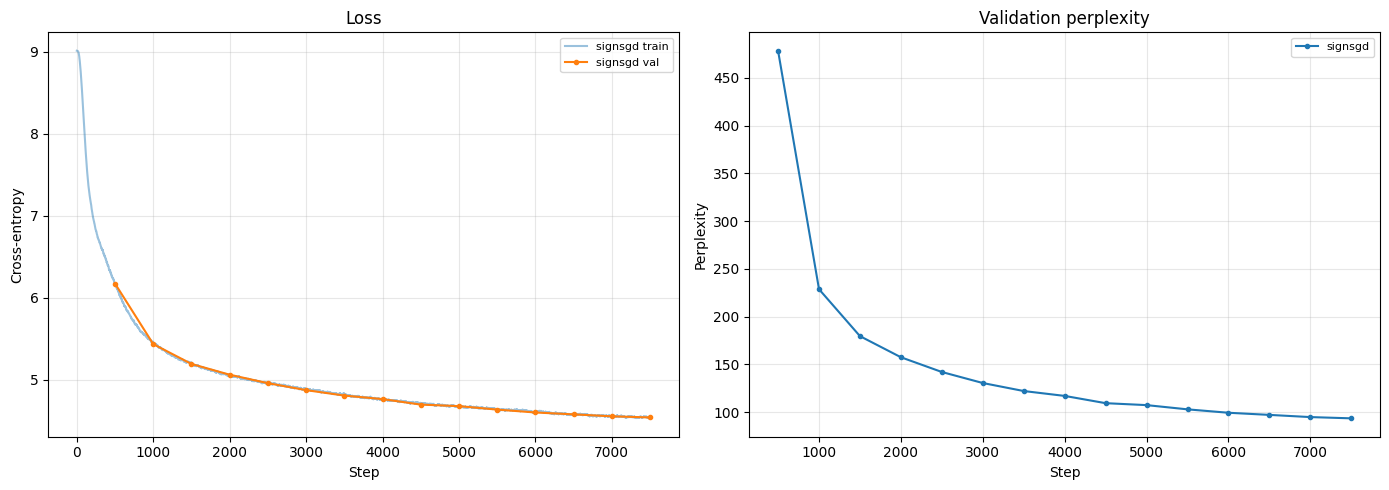

signsgd              step=07510 train=4.5325 lr=2.95e-05
signsgd              step=07520 train=4.5342 lr=2.87e-05
signsgd              step=07530 train=4.5366 lr=2.79e-05
signsgd              step=07540 train=4.5375 lr=2.72e-05
signsgd              step=07550 train=4.5431 lr=2.64e-05
signsgd              step=07560 train=4.5403 lr=2.56e-05
signsgd              step=07570 train=4.5373 lr=2.48e-05
signsgd              step=07580 train=4.5336 lr=2.40e-05
signsgd              step=07590 train=4.5371 lr=2.32e-05
signsgd              step=07600 train=4.5467 lr=2.24e-05
signsgd              step=07610 train=4.5351 lr=2.17e-05
signsgd              step=07620 train=4.5415 lr=2.09e-05
signsgd              step=07630 train=4.5343 lr=2.01e-05
FINAL signsgd: val_loss=4.5357, ppl=93.3, steps=7630
Wrote sweep summary: /mloscratch/homes/aabdolla/results/demo_signsgd_downstream_proxy_cm2_new/demo_signsgd_downstream_proxy_summary.json


In [9]:
ALL_RESULTS = {}
ALL_HISTORIES = {}
LAST_MODEL = None

CFG['experiment']['run_keys'] = ['signsgd']

CFG['selection']['proxy_source'] = 'downstream'
CFG['selection']['proxy_tasks'] = [
    'hellaswag',
    'arc_easy',
    'arc_challenge',
    'openbookqa',
]

CFG['selection']['candidate_multiplier'] = 2
CFG['selection']['use_countsketch'] = True
CFG['selection']['sketch_dim'] = 16384
CFG['selection']['countsketch_token_block'] = 128
CFG['selection']['val_proxy_size'] = 8192
CFG['selection']['proxy_batch_size'] = 32
CFG['selection']['candidate_chunk_size'] = 16

# Optional but nice: avoid mixing outputs with the previous sweep
CFG['paths']['results_dir'] = '/mloscratch/homes/aabdolla/results/demo_signsgd_downstream_proxy_cm2_new'
Path(CFG['paths']['results_dir']).expanduser().mkdir(parents=True, exist_ok=True)

validate_selection_proxy(CFG)

for run_key in CFG['experiment']['run_keys']:
    result, LAST_MODEL = run_experiment(run_key, CFG, live_histories=ALL_HISTORIES)
    ALL_RESULTS[run_key] = result
    ALL_HISTORIES[run_key] = result['history']
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

summary_path = Path(CFG['paths']['results_dir']).expanduser() / 'demo_signsgd_downstream_proxy_summary.json'
summary_path.write_text(json.dumps(ALL_RESULTS, indent=2))
print(f'Wrote sweep summary: {summary_path}')

## 10. Compare Results

This cell reads the in-memory run histories and plots final curves. Re-run it after loading `demo_sweep_summary.json` if you restart the kernel.


In [ ]:
if 'ALL_RESULTS' not in globals() or not ALL_RESULTS:
    summary_path = Path(CFG['paths']['results_dir']).expanduser() / 'demo_sweep_summary.json'
    ALL_RESULTS = json.loads(summary_path.read_text())
    ALL_HISTORIES = {k: v['history'] for k, v in ALL_RESULTS.items()}

plot_history(ALL_HISTORIES)

print('Final validation results:')
for run_key, result in sorted(ALL_RESULTS.items(), key=lambda item: item[1]['final_val_loss']):
    print(
        f"{run_key:20s} loss={result['final_val_loss']:.4f} "
        f"ppl={result['final_val_ppl']:.1f} steps={result['steps']}"
    )


## 11. lm-evaluation-harness Zero-shot Evaluation

This optional cell evaluates the last trained notebook model through the official harness API using a custom `LM` wrapper. It uses the task names and few-shot/limit settings from `demo_config.yaml`.


In [ ]:
try:
    import typing_extensions as _typing_extensions
    _typing_extensions.TypedDict('_LmEvalTypedDictProbe', {}, extra_items=int)
except TypeError as exc:
    raise ImportError(
        'lm-evaluation-harness requires typing_extensions with TypedDict extra_items support. '
        'Run the dependency-install cell, then restart the kernel so the upgraded '
        'typing_extensions>=4.13.2 is imported.'
    ) from exc

try:
    import lm_eval
    from lm_eval.evaluator import simple_evaluate as lm_eval_simple_evaluate
    from lm_eval import utils as lm_eval_utils
    from lm_eval.api.model import LM
except ImportError as exc:
    raise ImportError(
        'Run the dependency-install cell first; it installs lm_eval>=0.4.12 '
        'and typing_extensions>=4.13.2.'
    ) from exc


class DemoHarnessLM(LM):
    def __init__(self, model, tokenizer, bos_token_id, max_length, device, batch_size=8):
        super().__init__()
        self.model = model
        self.tokenizer = tokenizer
        self.bos_token_id = int(bos_token_id)
        self._max_length = int(max_length)
        self._batch_size = int(batch_size)
        self._device = torch.device(device)
        self.model.eval()

    @property
    def batch_size(self):
        return self._batch_size

    @property
    def max_length(self):
        return self._max_length

    @property
    def eot_token_id(self):
        return self.bos_token_id

    @property
    def tokenizer_name(self):
        return f"dclm-demo-byte-bpe-{DATA_METADATA['fingerprint']}"

    def tok_encode(self, text, add_special_tokens=False, **kwargs):
        ids = self.tokenizer.encode(text).ids
        return ([self.bos_token_id] + ids) if add_special_tokens else ids

    def tok_decode(self, ids):
        return self.tokenizer.decode([int(i) for i in ids])

    def _encode_pair(self, context, continuation):
        if context == '':
            return [self.bos_token_id], self.tok_encode(continuation, add_special_tokens=False)
        n_spaces = len(context) - len(context.rstrip())
        if n_spaces > 0:
            continuation = context[-n_spaces:] + continuation
            context = context[:-n_spaces]
        whole = self.tok_encode(context + continuation, add_special_tokens=False)
        context_ids = self.tok_encode(context, add_special_tokens=False) or [self.bos_token_id]
        continuation_ids = whole[len(context_ids):] if context_ids != [self.bos_token_id] else whole
        return context_ids, continuation_ids

    @torch.no_grad()
    def _score_encoded(self, encoded_pairs):
        outputs = []
        for batch_start in range(0, len(encoded_pairs), self._batch_size):
            batch = encoded_pairs[batch_start:batch_start + self._batch_size]
            prepared = []
            max_input_len = 1
            for context_ids, continuation_ids in batch:
                if not continuation_ids:
                    prepared.append(None)
                    continue
                full = list(context_ids) + list(continuation_ids)
                context_len = len(context_ids)
                if len(full) > self._max_length:
                    overflow = len(full) - self._max_length
                    full = full[overflow:]
                    context_len = max(1, context_len - overflow)
                inp_ids = full[:-1]
                tgt_ids = full[1:]
                cont_start = max(0, context_len - 1)
                cont_end = len(full) - 1
                max_input_len = max(max_input_len, len(inp_ids))
                prepared.append((inp_ids, tgt_ids, cont_start, cont_end))

            inp = torch.full((len(batch), max_input_len), self.bos_token_id, dtype=torch.long, device=self._device)
            tgt = torch.full((len(batch), max_input_len), -1, dtype=torch.long, device=self._device)
            for i, item in enumerate(prepared):
                if item is None:
                    continue
                inp_ids, tgt_ids, _, _ = item
                inp[i, :len(inp_ids)] = torch.tensor(inp_ids, dtype=torch.long, device=self._device)
                tgt[i, :len(tgt_ids)] = torch.tensor(tgt_ids, dtype=torch.long, device=self._device)

            with autocast_context():
                out = self.model(inp, targets=tgt.clamp(min=0), get_logits=True)
            logits = out['logits'] if isinstance(out, dict) else out[0]
            logp = F.log_softmax(logits.float(), dim=-1)

            for i, item in enumerate(prepared):
                if item is None:
                    outputs.append((0.0, True))
                    continue
                _, _, cont_start, cont_end = item
                if cont_end <= cont_start:
                    outputs.append((0.0, True))
                    continue
                target = tgt[i, cont_start:cont_end]
                token_logp = logp[i, cont_start:cont_end, :]
                valid = target >= 0
                gathered = token_logp.gather(1, target.clamp(min=0).unsqueeze(-1)).squeeze(-1)
                ll = gathered[valid].sum().item()
                greedy = (token_logp.argmax(dim=-1)[valid] == target[valid]).all().item()
                outputs.append((float(ll), bool(greedy)))
        return outputs

    def loglikelihood(self, requests, disable_tqdm=False):
        raw_args = [req.args for req in requests]
        encoded = [self._encode_pair(context, continuation) for context, continuation in raw_args]
        results = self._score_encoded(encoded)
        for args, result in zip(raw_args, results):
            self.cache_hook.add_partial('loglikelihood', args, result)
        return results

    def loglikelihood_rolling(self, requests, disable_tqdm=False):
        totals = []
        for req in requests:
            (text,) = req.args
            ids = self.tok_encode(text, add_special_tokens=False)
            if not ids:
                totals.append(0.0)
                continue
            windows = list(map(
                lm_eval_utils.make_disjoint_window,
                lm_eval_utils.get_rolling_token_windows(
                    token_list=ids,
                    prefix_token=self.bos_token_id,
                    max_seq_len=self._max_length,
                    context_len=1,
                ),
            ))
            total = sum(score[0] for score in self._score_encoded(windows))
            self.cache_hook.add_partial('loglikelihood_rolling', (text,), total)
            totals.append(float(total))
        return totals

    @torch.no_grad()
    def generate_until(self, requests, disable_tqdm=False):
        generations = []
        for req in requests:
            context, gen_kwargs = req.args
            until = gen_kwargs.get('until', []) if isinstance(gen_kwargs, dict) else []
            if isinstance(until, str):
                until = [until]
            max_gen_toks = int(gen_kwargs.get('max_gen_toks', 64)) if isinstance(gen_kwargs, dict) else 64
            ids = [self.bos_token_id] + self.tok_encode(context, add_special_tokens=False)
            generated = []
            text = ''
            for _ in range(max_gen_toks):
                x = torch.tensor([ids[-self._max_length:]], dtype=torch.long, device=self._device)
                with autocast_context():
                    out = self.model(x, get_logits=True)
                logits = out['logits'] if isinstance(out, dict) else out[0]
                next_id = int(torch.argmax(logits[:, -1, :], dim=-1).item())
                ids.append(next_id)
                generated.append(next_id)
                text = self.tok_decode(generated)
                stop_positions = [text.find(stop) for stop in until if stop and stop in text]
                if stop_positions:
                    text = text[:min(stop_positions)]
                    break
            generations.append(self.tok_decode(generated) if not until else text)
        return generations


def _json_default(obj):
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    return lm_eval_utils.handle_non_serializable(obj)


def run_lm_eval_harness(model, cfg):
    hcfg = cfg.get('evaluation', {}).get('lm_eval_harness', {})
    if not hcfg.get('enabled', False):
        print('lm-evaluation-harness is disabled in demo_config.yaml.')
        return None
    tasks = list(hcfg['tasks'])
    lm = DemoHarnessLM(
        model=model,
        tokenizer=tok_model,
        bos_token_id=BOS_TOKEN_ID,
        max_length=int(cfg['model']['max_seq_len']),
        device=device,
        batch_size=int(hcfg.get('batch_size', 8)),
    )
    kwargs = {
        'model': lm,
        'tasks': tasks,
        'num_fewshot': int(hcfg.get('num_fewshot', 0)),
        'batch_size': int(hcfg.get('batch_size', 8)),
        'bootstrap_iters': int(hcfg.get('bootstrap_iters', 100000)),
        'log_samples': bool(hcfg.get('log_samples', False)),
    }
    if hcfg.get('limit', None) is not None:
        kwargs['limit'] = hcfg['limit']
    results = lm_eval_simple_evaluate(**kwargs)
    out_path = Path(cfg['paths']['results_dir']).expanduser() / 'lm_eval_harness_results.json'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(results, indent=2, default=_json_default))
    print(f'Wrote lm-evaluation-harness results: {out_path}')
    for task, metrics in results.get('results', {}).items():
        scalars = {
            k: v for k, v in metrics.items()
            if not k.endswith(',stderr') and isinstance(v, (int, float, np.floating))
        }
        print(f"{task}: " + ', '.join(f'{k}={float(v):.4f}' for k, v in scalars.items()))
    return results


if LAST_MODEL is None:
    print('No model is loaded in LAST_MODEL. Run at least one experiment first.')
else:
    LM_EVAL_RESULTS = run_lm_eval_harness(LAST_MODEL, CFG)


## 12. Text Generation

Generate from the last trained model in the sweep.


In [ ]:
@torch.no_grad()
def generate(model, prompt='', max_tokens=200, temperature=0.8, top_k=50):
    model.eval()
    if prompt:
        token_ids = [BOS_TOKEN_ID] + tok_model.encode(prompt).ids
    else:
        token_ids = [BOS_TOKEN_ID]
    tokens = torch.tensor([token_ids], dtype=torch.long, device=device)
    seq_len = int(CFG['model']['max_seq_len'])

    for _ in range(int(max_tokens)):
        if tokens.size(1) > seq_len:
            tokens = tokens[:, -seq_len:]
        with autocast_context():
            out = model(tokens, get_logits=True)
        logits = out['logits'][:, -1, :] / float(temperature)
        if top_k and top_k > 0:
            topk_vals, _ = torch.topk(logits, min(int(top_k), logits.size(-1)))
            logits[logits < topk_vals[:, -1:]] = float('-inf')
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)
        tokens = torch.cat([tokens, next_token], dim=1)

    ids = tokens[0].tolist()
    if ids and ids[0] == BOS_TOKEN_ID:
        ids = ids[1:]
    return tok_model.decode(ids)


if LAST_MODEL is None:
    print('No model is loaded in LAST_MODEL. Run at least one experiment first.')
else:
    for prompt in ['The', 'In the beginning', 'Science is']:
        print(f'\nPrompt: {prompt!r}')
        print('-' * 40)
        print(generate(LAST_MODEL, prompt=prompt, max_tokens=150, temperature=0.8)[:800])
